In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score
import xgboost as xgp

In [2]:
np.random.seed(42)

In [4]:
results = pd.read_csv(r"C:\Users\surya_enldmg1\OneDrive\Documents\F1_Race_Prediction\data\results.csv")
races = pd.read_csv(r"C:\Users\surya_enldmg1\OneDrive\Documents\F1_Race_Prediction\data\races.csv")
drivers = pd.read_csv(r"C:\Users\surya_enldmg1\OneDrive\Documents\F1_Race_Prediction\data\drivers.csv")
constructors = pd.read_csv(r"C:\Users\surya_enldmg1\OneDrive\Documents\F1_Race_Prediction\data\constructors.csv")

In [5]:
races_modern = races[races['year'] >= 2014][['raceId', 'year', 'round', 'circuitId', 'name']]
races_modern.rename(columns={'name': 'race_name'}, inplace=True)

In [6]:
df = results.merge(races_modern, on='raceId', how='inner')
df = df.merge(drivers[['driverId', 'driverRef', 'dob']], on='driverId', how='left')
df = df.merge(constructors[['constructorId', 'constructorRef']], on='constructorId', how='left')
df['positionOrder'] = pd.to_numeric(df['positionOrder'], errors='coerce')
df['grid'] = pd.to_numeric(df['grid'], errors='coerce')
df = df.dropna(subset=['positionOrder', 'grid'])

In [7]:
df.head(3)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,fastestLapTime,fastestLapSpeed,statusId,year,round,circuitId,race_name,driverRef,dob,constructorRef
0,22130,900,3,131,6,3.0,1,1,1,25.0,...,1:32.478,206.436,1,2014,1,1,Australian Grand Prix,rosberg,1985-06-27,mercedes
1,22131,900,825,1,20,4.0,2,2,2,18.0,...,1:33.066,205.131,1,2014,1,1,Australian Grand Prix,kevin_magnussen,1992-10-05,mclaren
2,22132,900,18,1,22,10.0,3,3,3,15.0,...,1:32.917,205.46,1,2014,1,1,Australian Grand Prix,button,1980-01-19,mclaren


In [8]:
df['dob'] = pd.to_datetime(df['dob'])
df['driver_age'] = df['year'] - df['dob'].dt.year
df['grid'] = df['grid'].astype(int)
df['target_position'] = df['positionOrder'].astype(float)
df = df.sort_values(['driverId', 'year', 'round'])
df['driver_last5_avg_pos'] = df.groupby('driverId')['target_position'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

df['team_last5_avg_pos'] = df.groupby('constructorId')['target_position'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

df['driver_last5_avg_pos'] = df['driver_last5_avg_pos'].fillna(df['grid'])
df['team_last5_avg_pos'] = df['team_last5_avg_pos'].fillna(df['grid'])

df['driver_code'] = df['driverRef'].astype('category').cat.codes
df['constructor_code'] = df['constructorRef'].astype('category').cat.codes
df['circuit_code'] = df['circuitId'].astype('category').cat.codes

features = [
    'grid', 'year', 'round', 'driver_age', 
    'driver_last5_avg_pos', 'team_last5_avg_pos',
    'driver_code', 'constructor_code', 'circuit_code'
]

X = df[features]
y = df['target_position']


In [9]:
train_mask = df['year'] < 2023
test_mask = df['year'] >= 2023

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

In [30]:
model = xgp.XGBRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [31]:
model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [32]:
y_pred = model.predict(X_test)

In [33]:
y_pred_bounded = np.clip(y_pred, 1, 20)

In [34]:
mae = mean_absolute_error(y_test, y_pred_bounded)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_bounded))

In [35]:
mae

3.4575482846467995

In [36]:
rmse

np.float64(4.394966973396508)

In [37]:
y_test_podium = (y_test <= 3).astype(int)
y_pred_podium = (y_pred_bounded <= 3.5).astype(int)
podium_acc = accuracy_score(y_test_podium, y_pred_podium)

In [38]:
print("--- Model Evaluation (2023-2024 Test Set) ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} positions")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Podium Prediction Accuracy: {podium_acc * 100:.2f}%")

--- Model Evaluation (2023-2024 Test Set) ---
Mean Absolute Error (MAE): 3.46 positions
Root Mean Squared Error (RMSE): 4.39
Podium Prediction Accuracy: 85.26%


C:\Users\surya_enldmg1\AppData\Local\Temp\ipykernel_11656\1145331808.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


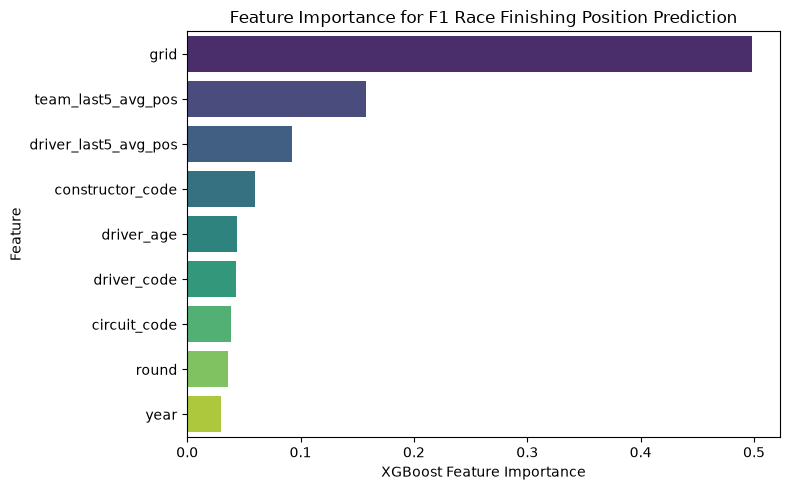

In [39]:
importances = model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance for F1 Race Finishing Position Prediction')
plt.xlabel('XGBoost Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()